In [ ]:

import pandas as pd
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [ ]:
(0.029661*0.0326531)/(0.0198547*0.0609756)

0.9999972946562095

In [314]:
data = []
for i in range(20):
    data.append(pd.read_csv(f"/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/teste{i}.csv",header= None))


In [315]:

inicial_nodes = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/grafo_0.csv",header=None)

In [317]:
inicial_set = set(map(tuple, inicial_nodes.values.tolist()))


def isin_row(row):
    # use iloc to get positional columns 0 and 1
    a = row.iloc[0]
    b = row.iloc[1]
    # optionally cast types if needed: (str(a), str(b))
    if ((a, b) in inicial_set) or ((b, a) in inicial_set):
        return "s"
    else:
        return "o"

In [318]:

data[10]["color"] = data[10].apply(isin_row,axis = 1)
data[19].value_counts(1,ascending=False).values[1:]

array([249, 205, 162, ...,   1,   1,   1], shape=(4193,))

In [319]:
len(data[19][[0,1]].value_counts(1).values)

4194

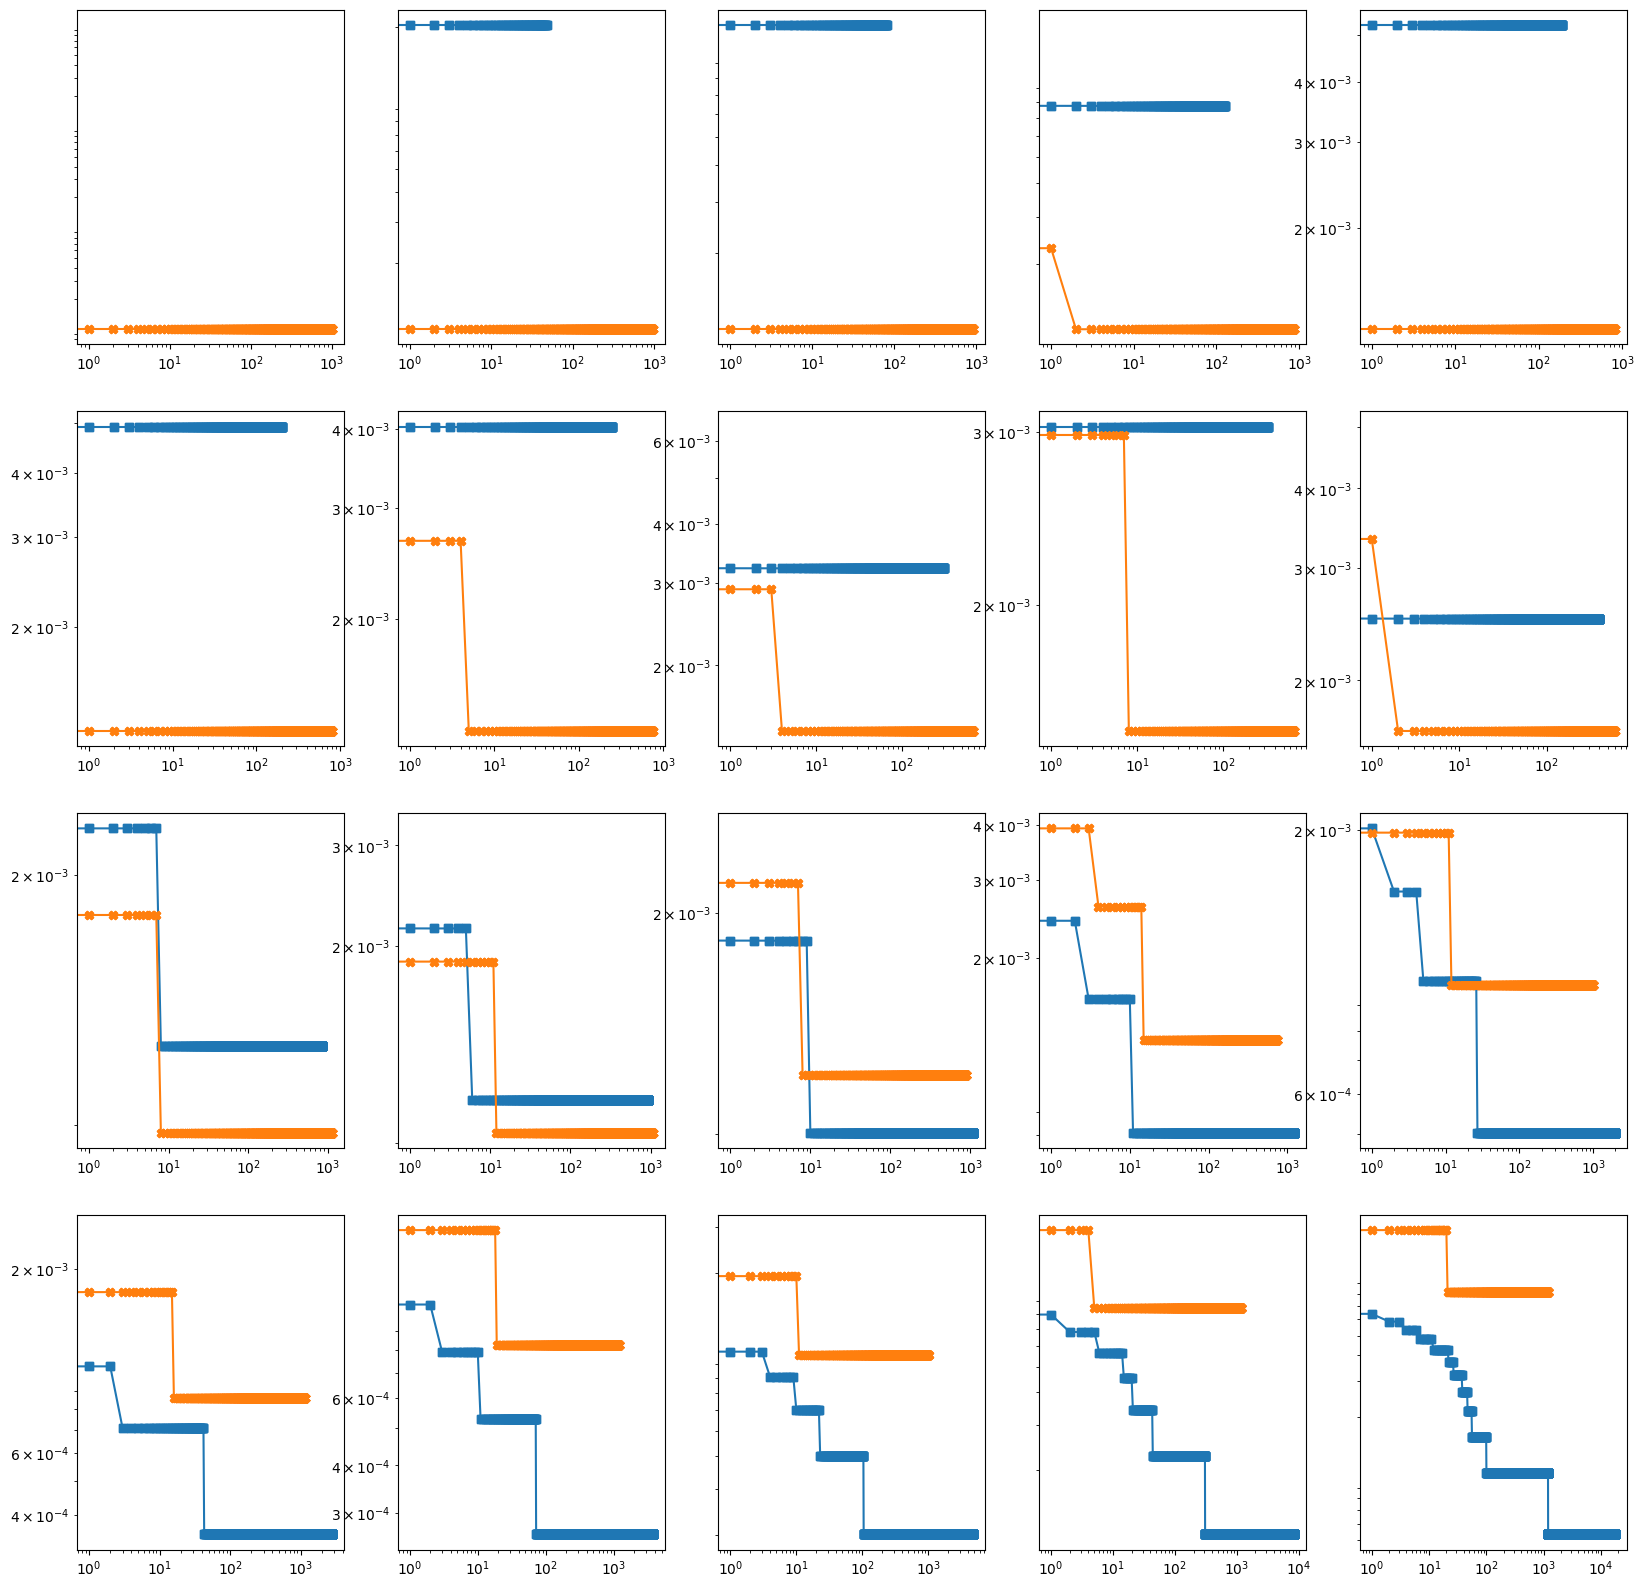

In [320]:
fig, ax = plt.subplots(4,5,figsize = (20,20))


for x in range(0,4):
    for y in range(5):
        i = 5*x+y
        data[i]["color"] = data[i].apply(isin_row,axis = 1)
        c = max(data[i].value_counts(1,ascending=False).values[1:]) 
        original_nodes = data[i][data[i]["color"] == "s"]
        new_nodes = data[i][data[i]["color"]== "o"]


        
        ax[x,y].scatter([i for i in range(len(original_nodes.value_counts(ascending=False).values))],[i for i in original_nodes.value_counts(ascending=False,normalize=True).values],marker="s")
        ax[x,y].plot([i for i in range(len(original_nodes.value_counts(ascending=False).values))],[i for i in original_nodes.value_counts(ascending=False,normalize=True).values],marker="s")
        ax[x,y].scatter([i for i in range(len(new_nodes.value_counts(ascending=False).values))],[i for i in new_nodes.value_counts(ascending=False,normalize=True).values],marker="X")
        ax[x,y].plot([i for i in range(len(new_nodes.value_counts(ascending=False).values))],[i for i in new_nodes.value_counts(ascending=False,normalize=True).values],marker="X")

        ax[x,y].loglog("True")

# plt.xlabel("ID nó")
# plt.ylabel("Quantida de aparições")
# plt.loglog(True)
plt.show()

In [146]:
aux = data[0][1].values.reshape(25000,-1)

In [321]:
all_views = []
for i in range(0,20):
    data[i]["color"] = data[i].apply(isin_row,axis = 1)
    new_nodes = data[i][data[i]["color"]== "o"]
    new_nodes = new_nodes[[0,1]].apply(lambda row: frozenset([row[0], row[1]]), axis=1).value_counts()
    vc = new_nodes.reset_index(name=i+2)
    vc.columns = [0, i+1]
    all_views.append(vc)


In [322]:
fn = all_views[0].copy()
for i in range(1,20):
    fn = fn.merge(all_views[i],on=[0],how = "outer")

In [310]:
fn = fn.fillna(0)


In [299]:
fn[20].value_counts().values[0:]

array([796884,   3706,    968,     33,     13])

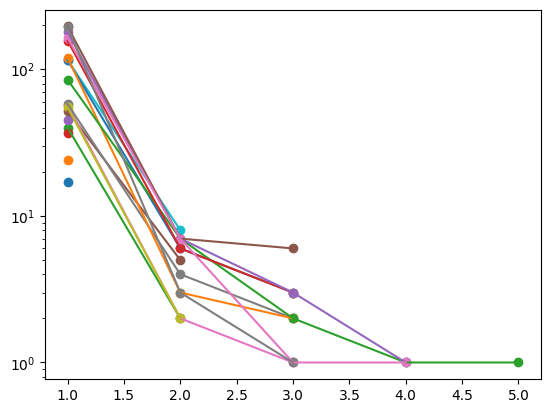

In [323]:
for j in range(2,20):
    plt.scatter([i+1 for i in range(len(fn[j].value_counts().values[1:]))],fn[j].value_counts().values[1:])
    plt.plot([i+1 for i in range(len(fn[j].value_counts().values[1:]))],fn[j].value_counts().values[1:])

plt.yscale("log")
plt.show()


In [16]:
grafo_original = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/grafo_0.csv",header=None)
grafo_invertido = grafo_original.rename(columns={0: 1, 1: 0})[[0,1]]

# Concatena os dois
grafo = pd.concat([grafo_original, grafo_invertido], ignore_index=True)

In [17]:
grafo

,0,1
0,107,1
1,107,356
2,107,502
3,107,551
4,107,589
...,...,...
149117,8636,138327
149118,41566,138327
149119,4867,138327
149120,83324,138327


In [105]:
mapa = grafo.groupby(0)[1].apply(set).to_dict()


In [78]:
ps = []
# start with a list of keys (not a list containing a dict_keys object)
indexes = list(mapa.keys())
i = 1

to_compare = list(mapa.get(107, []))
if not to_compare:
    print("node 107 has no neighbors")
else:
    while True:
        aux = 0
        new_indexes = []

        if i >= len(to_compare):
            break
        target = to_compare[i]

        for value in indexes:
            if target in mapa.get(value, set()):
                new_indexes.append(value)
                aux += 1

        if len(indexes) == 0:
            break
        ps.append(aux / len(indexes))

        i += 1
        indexes = new_indexes
        print(indexes)
        if len(indexes) <= 1:
            break

    print(ps)

[107, 2051, 2442, 5515, 10419, 15371, 16785, 17963, 18199, 18611, 20646, 22454, 26869, 27942, 28744, 29328, 32670, 32723, 34294, 34723, 36604, 39074, 42639, 49863, 50971, 52317, 53372, 55071, 55099, 55522, 57494, 58904, 60016, 64652, 65184, 65413, 65830, 66774, 69630, 74902, 76855, 78643, 78728, 79304, 84476, 88041, 88947, 92715, 97890, 99472, 103713, 105131, 110889, 111038, 112116, 113063, 115825, 117984, 118355, 118941, 120666, 121779, 121804, 121894, 122428, 122697, 130871, 135123, 135780, 136294]
[107, 18611, 27942, 60016, 78728]
[107, 18611, 60016]
[107]
[0.00847457627118644, 0.07142857142857142, 0.6, 0.3333333333333333]


In [ ]:
#probabilidade do nó um estar ligado ao nó dois dado a vizinhança do nó um 
def condicional_prob(graph,node_1,node_2):


    mapa = graph.groupby(0)[1].apply(set).to_dict()

    p_cima,p_baixo = [len(mapa.get(node_2,[]))/len(mapa)],[]

    vizinhança_node_1 = list(mapa.get(node_1,[]))
    p_baixo.append(len(mapa.get(vizinhança_node_1[1],[]))/len(mapa))

    i = 0

    condicionante_cima = mapa.get(node_2,set())
    condionate_baixo = mapa.get(vizinhança_node_1[1],set())



    while True:
        (mapa.get(vizinhança_node_1[i],set())).intersection(condicionante_cima)
        p_cima.append(len(list((mapa.get(vizinhança_node_1[i],set()).intersection(condicionante_cima))))/ len(list(condicionante_cima)))
        condicionante_cima = mapa.get(vizinhança_node_1[i],set()).intersection(condicionante_cima)
        i += 1 
        print(len(condicionante_cima))
        if len(list(condicionante_cima)) <= 1:
            break
    i = 2

    # vizinhança_node_1 = list(mapa.get(node_1,[]))

    while True:
        (mapa.get(vizinhança_node_1[i],set())).intersection(condionate_baixo)
        p_baixo.append(len(list((mapa.get(vizinhança_node_1[i],set()).intersection(condionate_baixo))))/ len(list(condionate_baixo)))
        condionate_baixo = mapa.get(vizinhança_node_1[i],set()).intersection(condionate_baixo)
        i += 1 
        print(len(condionate_baixo))
        if len(list(condionate_baixo))  <= 1 :
            break

        aux = 1
        for i in ps[0]:
            aux = aux*i

        for j in ps[1]:
            aux = aux/j
        return aux


164
44
4
3
1
5
3
1


In [162]:
condicional_prob(grafo,107)

1
[0.019854721549636804, 0.2682926829268293, 0.09090909090909091, 0.75, 0.3333333333333333]
[0.00847457627118644, 0.07142857142857142, 0.6, 0.3333333333333333]


1.0

In [180]:
print(p_baixo,p_cima)


[0.00847457627118644, 0.07142857142857142, 0.6, 0.3333333333333333] [0.019854721549636804, 1.0, 0.2682926829268293, 0.09090909090909091, 0.75, 0.3333333333333333]


In [181]:
(0.00847457627118644*0.07142857142857142*0.6*0.3333333333333333)/(0.019854721549636804*1.0*0.2682926829268293*0.09090909090909091*0.75*0.3333333333333333)


0.9999999999999999

In [ ]:
def condicional_prob(graph,node):

    mapa = graph.groupby(0)[1].apply(set).to_dict()
    
    ps = [[],[]]
    # start with a list of keys (not a list containing a dict_keys object)
    indexes = list(mapa.keys())
    i = 0


    to_compare = list(mapa.get(node, []))
    if not to_compare:
        print("node {node} has no neighbors")
    else:
        while True:
            aux = 0
            new_indexes = []

            if i >= len(to_compare):
                break
            target = to_compare[i]

            for value in indexes:
                if target in mapa.get(value, set()):
                    new_indexes.append(value)
                    aux += 1
            if len(indexes) == 0:
                break
            ps[0].append(aux / len(indexes))

            i += 1
            indexes = new_indexes
            if len(indexes) <= 1:
                break

        i = 1

        indexes = list(mapa.keys())

        to_compare = list(mapa.get(node, []))
        if not to_compare:
            print("node 107 has no neighbors")
        else:
            while True:
                aux = 0
                new_indexes = []

                if i >= len(to_compare):
                    break
                target = to_compare[i]

                for value in indexes:
                    if target in mapa.get(value, set()):
                        new_indexes.append(value)
                        aux += 1

                if len(indexes) == 0:
                    break
                ps[1].append(aux / len(indexes))
                i += 1
                indexes = new_indexes
                if len(indexes) <= 1:
                    break
        print(ps[0])
        print(ps[1])
        aux = 1
        for i in ps[0]:
            aux = aux*i

        for j in ps[1]:
            aux = aux/j
        return aux

In [76]:
p_baixo

[0.019854721549636804,
 0.2682926829268293,
 0.09090909090909091,
 0.75,
 0.3333333333333333]

In [77]:
p_cima

[0.029661016949152543, 0.15151515151515152, 0.5, 0.0]

In [74]:
(0.019854721549636804 * 0.2682926829268293 * 0.09090909090909091 * 0.75 * 0.3333333333333333)/(0.029661016949152543*0.15151515151515152*0.5)

0.05387755102040815

In [48]:
aux1 = [0.3203125, 0.2682926829268293, 0.09090909090909091, 0.75, 0.3333333333333333]
aux2 = [0.13671875, 0.07142857142857142, 0.6, 0.3333333333333333]

aux3 = 1
for i in aux1:
    aux3 = aux3*i

for i in aux2:
    aux3 = aux3/i

print(aux3)

1.0000000000000002
